# CRT Physics-Based Generative Image Model — Training Notebook

This notebook trains a CRT physics-based generative renderer on **ready-made image datasets** automatically.

Default training dataset:

```text
CIFAR10
```

You can switch to:

```python
cfg.dataset_name = "MNIST"
cfg.dataset_name = "FashionMNIST"
cfg.dataset_name = "STL10"
cfg.dataset_name = "CUSTOM"
```

If you choose `CUSTOM`, put your own images inside:

```text
data/images/
```

The implemented model follows the CRT mathematical pipeline:

electron acceleration and deflection sensitivity
raster scan trajectory
finite Gaussian beam spot
phosphor persistence approximation
latent-controlled voltage / brightness signals
trainable physics-constrained image generator
reconstruction, physics consistency, smoothness, and signal regularization losses



## Install / Imports


In [11]:
import os, math, random, time
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE =', DEVICE)

DEVICE = cuda


## Configuration

For quick debugging, use `img_size=32`, `n_steps=1024`. For better results, try `64` and `4096+`.

In [12]:
@dataclass
class CFG:

    dataset_name: str = "CIFAR10"
    download_data: bool = True
    data_root: str = "data/ready_datasets"
    data_dir: str = "data/images"
    max_train_samples: int | None = 5000

    out_dir: str = "outputs_crt"

    img_size: int = 32
    batch_size: int = 16
    epochs: int = 10
    lr: float = 2e-4
    latent_dim: int = 128
    n_steps: int = 1024
    neighbor_radius: int = 2

    frame_rate: float = 60.0
    va: float = 15000.0
    lx: float = 0.03
    ly: float = 0.03
    dx: float = 0.005
    dy: float = 0.005
    Dx: float = 0.12
    Dy: float = 0.12

    lambda_recon: float = 1.0
    lambda_smooth: float = 0.02
    lambda_range: float = 0.005
    lambda_physics: float = 0.01
    seed: int = 42

cfg = CFG()
Path(cfg.out_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.data_root).mkdir(parents=True, exist_ok=True)
random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
print(cfg)


CFG(dataset_name='CIFAR10', download_data=True, data_root='data/ready_datasets', data_dir='data/images', max_train_samples=5000, out_dir='outputs_crt', img_size=32, batch_size=16, epochs=10, lr=0.0002, latent_dim=128, n_steps=1024, neighbor_radius=2, frame_rate=60.0, va=15000.0, lx=0.03, ly=0.03, dx=0.005, dy=0.005, Dx=0.12, Dy=0.12, lambda_recon=1.0, lambda_smooth=0.02, lambda_range=0.005, lambda_physics=0.01, seed=42)


## Dataset Loader

This loader accepts `.jpg`, `.jpeg`, `.png`, `.webp`, `.bmp`. It converts all images to RGB and resizes them.

In [13]:
from torch.utils.data import Subset
from torchvision import datasets

class FlatImageDataset(Dataset):
    """Custom image folder dataset. Used when cfg.dataset_name == "CUSTOM"."""
    def __init__(self, root, img_size=64):
        self.root = Path(root)
        exts = ["*.jpg", "*.jpeg", "*.png", "*.webp", "*.bmp"]
        self.paths = []
        for ext in exts:
            self.paths += list(self.root.rglob(ext))
        self.paths = sorted(self.paths)
        if len(self.paths) == 0:
            raise FileNotFoundError(
                f"No images found in {self.root.resolve()}. Put training images in {root}/"
            )
        self.tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.tf(img), str(self.paths[idx])


class ImageOnlyWrapper(Dataset):
    """Normalizes torchvision datasets to return (image, source_label)."""
    def __init__(self, base_dataset, source_name):
        self.base = base_dataset
        self.source_name = source_name

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, _label = self.base[idx]
        return x, self.source_name


def _rgb_transform(img_size):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.Lambda(lambda img: img.convert("RGB")),
        transforms.ToTensor(),
    ])


def build_dataset(cfg):
    name = cfg.dataset_name.upper()
    tf = _rgb_transform(cfg.img_size)

    if name == "CIFAR10":
        base = datasets.CIFAR10(root=cfg.data_root, train=True, download=cfg.download_data, transform=tf)
        ds = ImageOnlyWrapper(base, "CIFAR10")

    elif name == "MNIST":
        base = datasets.MNIST(root=cfg.data_root, train=True, download=cfg.download_data, transform=tf)
        ds = ImageOnlyWrapper(base, "MNIST")

    elif name == "FASHIONMNIST":
        base = datasets.FashionMNIST(root=cfg.data_root, train=True, download=cfg.download_data, transform=tf)
        ds = ImageOnlyWrapper(base, "FashionMNIST")

    elif name == "STL10":
        base = datasets.STL10(root=cfg.data_root, split="train", download=cfg.download_data, transform=tf)
        ds = ImageOnlyWrapper(base, "STL10")

    elif name == "CUSTOM":
        ds = FlatImageDataset(cfg.data_dir, cfg.img_size)

    else:
        raise ValueError(
            "Unknown dataset_name. Use CIFAR10, MNIST, FashionMNIST, STL10, or CUSTOM."
        )

    if cfg.max_train_samples is not None:
        n = min(cfg.max_train_samples, len(ds))
        ds = Subset(ds, list(range(n)))

    return ds


def build_loader(cfg):
    dataset = build_dataset(cfg)
    loader = DataLoader(
        dataset,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=(DEVICE == "cuda"),
        drop_last=True,
    )
    print(f"Dataset: {cfg.dataset_name} | samples used: {len(dataset)} | batches: {len(loader)}")
    return dataset, loader


dataset, loader = build_loader(cfg)
x_preview, _ = next(iter(loader))
show_images_available = "show_batch" in globals()
print("Preview batch shape:", tuple(x_preview.shape))


Dataset: CIFAR10 | samples used: 5000 | batches: 312
Preview batch shape: (16, 3, 32, 32)


## CRT Physics Utilities

Electron acceleration:

$$v = \sqrt{\frac{2 e V_a}{m}}$$

Electrostatic deflection sensitivity:

$$S_x = \frac{L_x}{2 d_x V_a}\left(D_x + \frac{L_x}{2}\right),\quad
S_y = \frac{L_y}{2 d_y V_a}\left(D_y + \frac{L_y}{2}\right)$$

In [14]:
E_CHARGE = 1.602176634e-19
E_MASS = 9.1093837015e-31
C_LIGHT = 299792458.0

def electron_velocity_nonrel(va: float) -> float:
    return math.sqrt(2 * E_CHARGE * va / E_MASS)

def relativistic_warning(va: float):
    v = electron_velocity_nonrel(va)
    ratio = v / C_LIGHT
    print(f'electron velocity ≈ {v:.3e} m/s = {ratio:.3f} c')
    if ratio > 0.2:
        print('Warning: relativistic correction may matter.')

relativistic_warning(cfg.va)

def deflection_sensitivities(cfg: CFG) -> Tuple[float, float]:
    sx = (cfg.lx / (2 * cfg.dx * cfg.va)) * (cfg.Dx + cfg.lx / 2)
    sy = (cfg.ly / (2 * cfg.dy * cfg.va)) * (cfg.Dy + cfg.ly / 2)
    return sx, sy

sx, sy = deflection_sensitivities(cfg)
print('Sx, Sy =', sx, sy)

electron velocity ≈ 7.264e+07 m/s = 0.242 c
Sx, Sy = 2.7e-05 2.7e-05


## Differentiable CRT Renderer

For each time step, the renderer has beam position `(x[n], y[n])`, color brightness `B[n]`, and Gaussian spot width `sigma`. It deposits energy into nearby pixels:

$$I(i,j)=\sum_n B(t_n)K(i-y(t_n), j-x(t_n))$$

Phosphor persistence is implemented approximately as causal temporal smoothing over beam brightness.

In [23]:
class CRTRenderer(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.cfg = cfg
        H = W = cfg.img_size
        N = cfg.n_steps

        idx = torch.arange(N).float()
        samples_per_line = max(1, N // H)
        y_base = torch.floor(idx / samples_per_line).clamp(0, H - 1)
        x_base = (idx % samples_per_line) / max(1, samples_per_line - 1) * (W - 1)

        self.register_buffer('x_base', x_base)
        self.register_buffer('y_base', y_base)
        self.register_buffer('t', torch.linspace(0, 1, N))

        offsets = []
        r = cfg.neighbor_radius
        for oy in range(-r, r + 1):
            for ox in range(-r, r + 1):
                offsets.append((oy, ox))
        self.offsets = offsets

    def apply_persistence(self, B, tau):
        batch, N, C = B.shape
        alpha = torch.sigmoid(tau).view(batch, 1) * 0.35 + 0.05
        out = []
        prev = torch.zeros(batch, C, device=B.device, dtype=B.dtype)
        for n in range(N):
            prev = alpha * B[:, n, :] + (1 - alpha) * prev
            out.append(prev)
        return torch.stack(out, dim=1)

    def forward(self, signal: Dict[str, torch.Tensor]):
        Vx = signal['Vx']
        Vy = signal['Vy']
        brightness = signal['B']
        sigma = signal['sigma']
        tau = signal['tau']

        batch = Vx.shape[0]
        H = W = self.cfg.img_size
        max_perturb = 0.12 * W

        x = self.x_base[None, :] + max_perturb * torch.tanh(Vx)
        y = self.y_base[None, :] + max_perturb * torch.tanh(Vy)
        x = x.clamp(0, W - 1)
        y = y.clamp(0, H - 1)

        Bp = self.apply_persistence(brightness, tau)

        img = torch.zeros(batch, 3, H, W, device=Vx.device, dtype=brightness.dtype)
        x0 = torch.round(x).long()
        y0 = torch.round(y).long()
        sigma_px = F.softplus(sigma).view(batch, 1) + 0.35

        for oy, ox in self.offsets:
            xi = (x0 + ox).clamp(0, W - 1)
            yi = (y0 + oy).clamp(0, H - 1)
            dist2 = (x - xi.float())**2 + (y - yi.float())**2
            weight = torch.exp(-dist2 / (2 * sigma_px**2)).unsqueeze(1)
            contrib = Bp.permute(0, 2, 1) * weight
            idx = (yi * W + xi).unsqueeze(1).expand(-1, 3, -1)
            img_flat = img.view(batch, 3, H * W)
            img_flat.scatter_add_(2, idx, contrib.to(img.dtype))

        img = img / (img.amax(dim=(1,2,3), keepdim=True) + torch.tensor(1e-6, device=img.device, dtype=img.dtype))
        return img.clamp(0, 1), {'x': x, 'y': y, 'Bp': Bp}

## Encoder + Signal Decoder

The encoder maps a target image to latent vector `z`. The decoder maps `z` to `Vx(t,z)`, `Vy(t,z)`, `B(t,z)`, `sigma(z)`, and `tau(z)`.

In [25]:
class ImageEncoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.SiLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.SiLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.SiLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.SiLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)
    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h)

def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

class SignalDecoder(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.cfg = cfg
        self.fc = nn.Sequential(
            nn.Linear(cfg.latent_dim, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
        )
        self.signal = nn.Linear(512, cfg.n_steps * 5)
        self.param = nn.Linear(512, 2)
    def forward(self, z):
        h = self.fc(z)
        raw = self.signal(h).view(z.shape[0], self.cfg.n_steps, 5)
        Vx = raw[:, :, 0]
        Vy = raw[:, :, 1]
        B = torch.sigmoid(raw[:, :, 2:5])
        p = self.param(h)
        sigma = p[:, 0:1]
        tau = p[:, 1:2]
        return {'Vx': Vx, 'Vy': Vy, 'B': B, 'sigma': sigma, 'tau': tau}

class CRTAutoEncoder(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.encoder = ImageEncoder(cfg.latent_dim)
        self.decoder = SignalDecoder(cfg)
        self.renderer = CRTRenderer(cfg)
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        signal = self.decoder(z)
        img, aux = self.renderer(signal)
        return img, signal, aux, mu, logvar

model = CRTAutoEncoder(cfg).to(DEVICE)
print('Model updated and re-instantiated.')
print('Parameters:', round(sum(p.numel() for p in model.parameters())/1e6, 3), 'M')

Model updated and re-instantiated.
Parameters: 3.713 M


## Loss Functions

Total objective combines reconstruction, signal smoothness, voltage range, physics consistency, and KL latent regularization.

In [19]:
def smoothness_loss(signal):
    return ((signal['Vx'][:, 1:] - signal['Vx'][:, :-1])**2).mean() + \
           ((signal['Vy'][:, 1:] - signal['Vy'][:, :-1])**2).mean() + \
           ((signal['B'][:, 1:] - signal['B'][:, :-1])**2).mean()

def range_loss(signal):
    return (torch.relu(signal['Vx'].abs() - 1.0)**2).mean() + \
           (torch.relu(signal['Vy'].abs() - 1.0)**2).mean()

def physics_consistency_loss(aux):
    x, y = aux['x'], aux['y']
    dx = x[:, 1:] - x[:, :-1]
    dy = y[:, 1:] - y[:, :-1]
    ddx = dx[:, 1:] - dx[:, :-1]
    ddy = dy[:, 1:] - dy[:, :-1]
    return (ddx**2).mean() + (ddy**2).mean()

def kl_loss(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

def total_loss(pred, target, signal, aux, mu, logvar, cfg):
    recon = F.mse_loss(pred, target) + 0.25 * F.l1_loss(pred, target)
    smooth = smoothness_loss(signal)
    rng = range_loss(signal)
    phys = physics_consistency_loss(aux)
    kl = kl_loss(mu, logvar)
    total = (cfg.lambda_recon * recon +
             cfg.lambda_smooth * smooth +
             cfg.lambda_range * rng +
             cfg.lambda_physics * phys +
             1e-4 * kl)
    return total, {
        'total': total.detach(), 'recon': recon.detach(), 'smooth': smooth.detach(),
        'range': rng.detach(), 'physics': phys.detach(), 'kl': kl.detach()
    }

## Visualization Helpers

In [20]:
def show_batch(x, title='images', max_n=4):
    x = x.detach().cpu().clamp(0,1)
    n = min(max_n, x.shape[0])
    plt.figure(figsize=(3*n,3))
    for i in range(n):
        plt.subplot(1,n,i+1)
        plt.imshow(x[i].permute(1,2,0))
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

def save_comparison(inp, out, path, max_n=4):
    inp = inp.detach().cpu().clamp(0,1)
    out = out.detach().cpu().clamp(0,1)
    n = min(max_n, inp.shape[0])
    plt.figure(figsize=(3*n,6))
    for i in range(n):
        plt.subplot(2,n,i+1); plt.imshow(inp[i].permute(1,2,0)); plt.axis('off'); plt.title('target')
        plt.subplot(2,n,n+i+1); plt.imshow(out[i].permute(1,2,0)); plt.axis('off'); plt.title('CRT recon')
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.close()

## Training Loop

This section trains immediately on the ready dataset selected in `cfg.dataset_name`.


```python
cfg.dataset_name = "CIFAR10"
```

To train on another ready dataset, change the config cell near the top and rerun the notebook


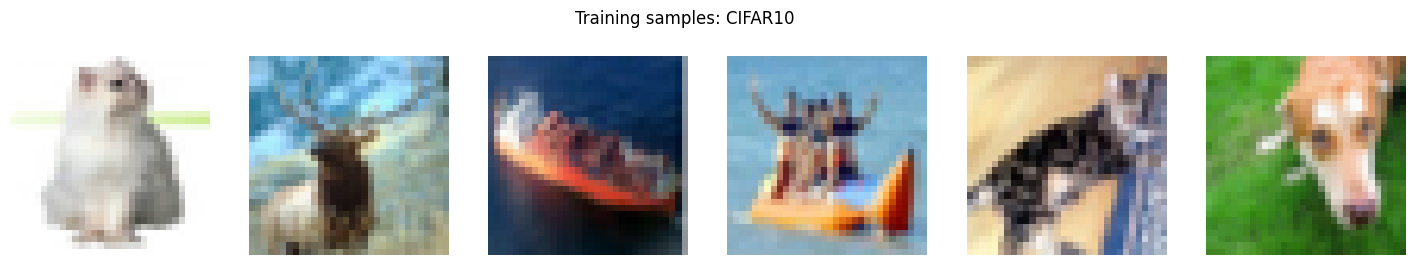

Epoch 1/10:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 6/10:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 7/10:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/312 [00:00<?, ?it/s]

In [26]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE=="cuda"))

def train(loader, model, optimizer, cfg):
    history = []
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{cfg.epochs}")
        running = {"total":0, "recon":0, "smooth":0, "range":0, "physics":0, "kl":0}
        count = 0

        for x, _paths in pbar:
            x = x.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=(DEVICE=="cuda")):
                pred, signal, aux, mu, logvar = model(x)
                loss, logs = total_loss(pred, x, signal, aux, mu, logvar, cfg)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            bs = x.shape[0]
            count += bs
            for k in running:
                running[k] += float(logs[k]) * bs

            pbar.set_postfix({
                "total": f'{running["total"] / count:.4f}',
                "recon": f'{running["recon"] / count:.4f}',
            })

        epoch_logs = {k: running[k] / count for k in running}
        history.append(epoch_logs)

        model.eval()
        with torch.no_grad():
            x0, _ = next(iter(loader))
            x0 = x0.to(DEVICE)
            y0, *_ = model(x0)

        save_comparison(x0, y0, f"{cfg.out_dir}/epoch_{epoch:03d}.png")
        torch.save(
            {"model": model.state_dict(), "cfg": cfg.__dict__, "history": history},
            f"{cfg.out_dir}/crt_model_latest.pt"
        )

    return history

show_batch(next(iter(loader))[0], f"Training samples: {cfg.dataset_name}", max_n=6)
history = train(loader, model, optimizer, cfg)

## Inference / Reconstruction

Load checkpoint and reconstruct new images through the CRT physics renderer.

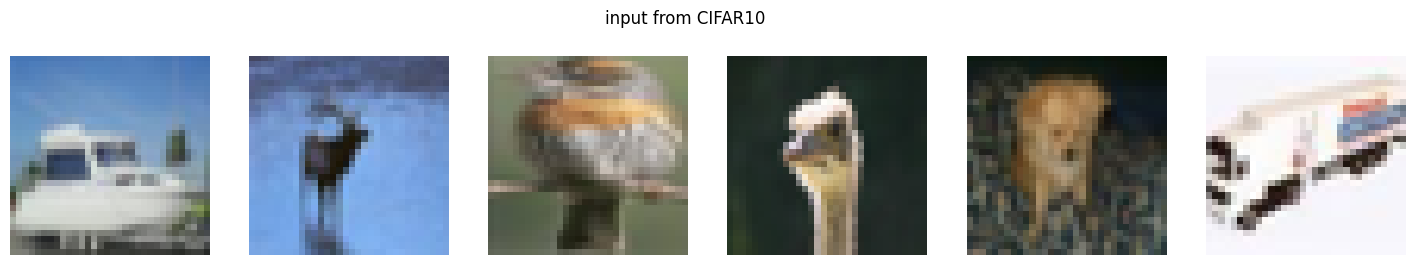

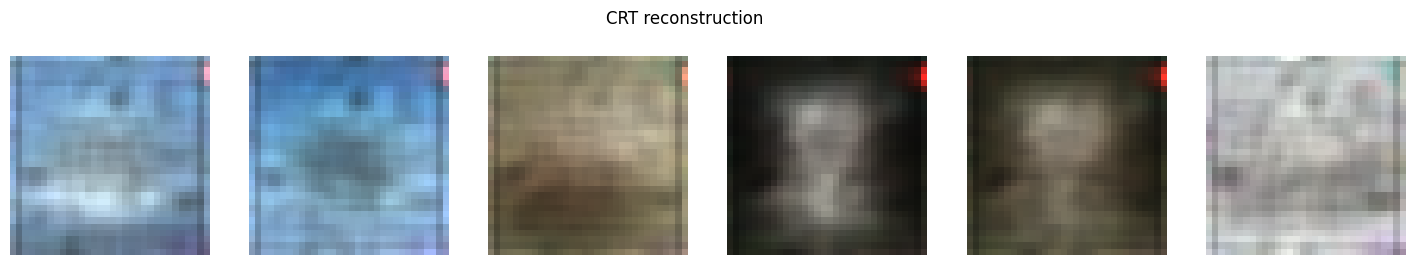

saved: outputs_crt/inference_comparison.png


In [31]:
def load_checkpoint(path="outputs_crt/crt_model_latest.pt"):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return ckpt


@torch.no_grad()
def reconstruct_ready_batch(max_images=8, checkpoint="outputs_crt/crt_model_latest.pt"):
    load_checkpoint(checkpoint)
    x, paths = next(iter(loader))
    x = x[:max_images].to(DEVICE)
    y, signal, aux, mu, logvar = model(x)
    show_batch(x, f"input from {cfg.dataset_name}", max_n=max_images)
    show_batch(y, "CRT reconstruction", max_n=max_images)
    save_comparison(x, y, f"{cfg.out_dir}/inference_comparison.png", max_n=max_images)
    print("saved:", f"{cfg.out_dir}/inference_comparison.png")
    return y, signal, aux, paths


@torch.no_grad()
def reconstruct_folder(image_folder, max_images=8, checkpoint="outputs_crt/crt_model_latest.pt"):
    load_checkpoint(checkpoint)
    ds = FlatImageDataset(image_folder, cfg.img_size)
    dl = DataLoader(ds, batch_size=min(max_images, cfg.batch_size), shuffle=False)
    x, paths = next(iter(dl))
    x = x.to(DEVICE)
    y, signal, aux, mu, logvar = model(x)
    show_batch(x, "custom input")
    show_batch(y, "CRT reconstruction")
    save_comparison(x, y, f"{cfg.out_dir}/custom_inference_comparison.png", max_n=max_images)
    print("saved:", f"{cfg.out_dir}/custom_inference_comparison.png")
    return y, signal, aux, paths


# After training:
y, signal, aux, paths = reconstruct_ready_batch(max_images=6)


## Generate From Random Latent Vector

Pure generative mode:

```text
z -> Vx,Vy,B,sigma,tau -> CRT renderer -> image
```

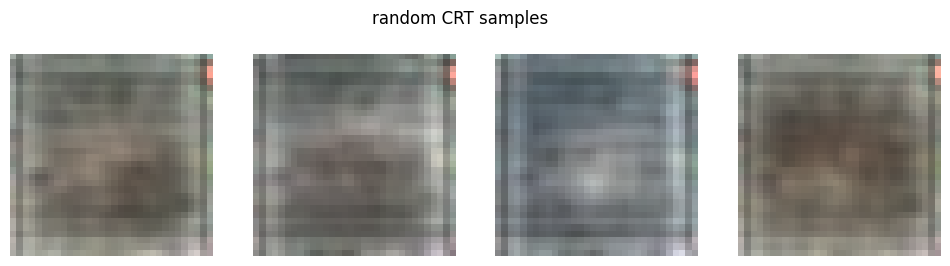

In [33]:
@torch.no_grad()
def generate_random(n=4, checkpoint='outputs_crt/crt_model_latest.pt'):
    load_checkpoint(checkpoint)
    z = torch.randn(n, cfg.latent_dim, device=DEVICE)
    signal = model.decoder(z)
    img, aux = model.renderer(signal)
    show_batch(img, 'random CRT samples', max_n=n)
    return img, signal, aux

samples, signal, aux = generate_random(4)

## Inspect CRT Signals

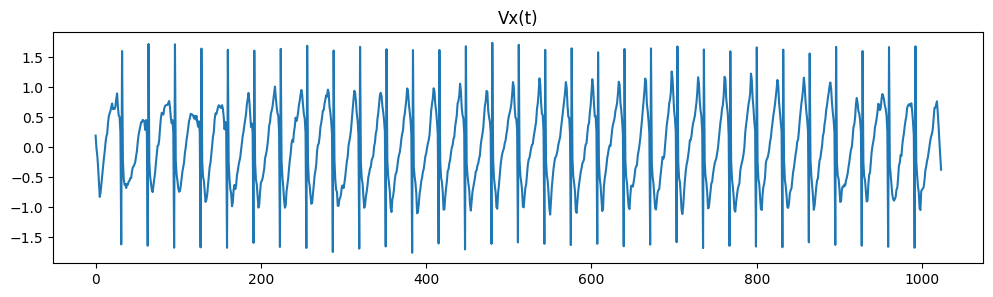

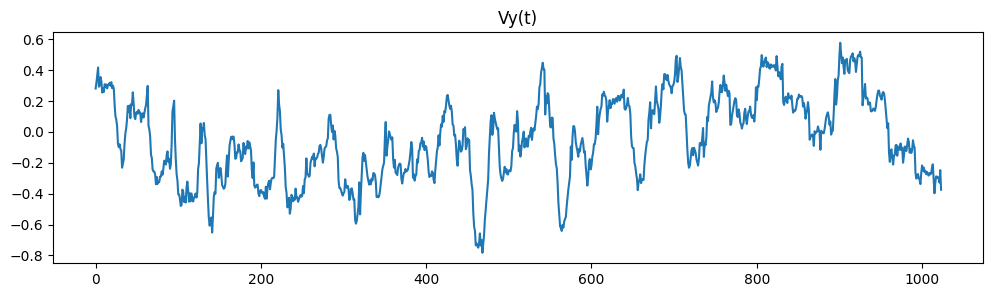

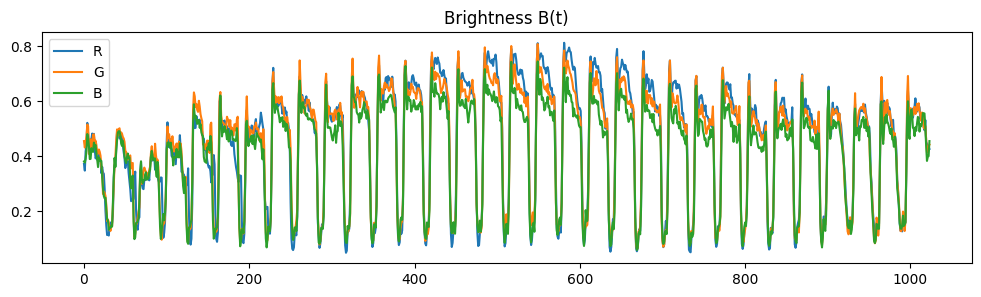

In [34]:
def plot_signals(signal, idx=0):
    Vx = signal['Vx'][idx].detach().cpu()
    Vy = signal['Vy'][idx].detach().cpu()
    B = signal['B'][idx].detach().cpu()
    plt.figure(figsize=(12,3)); plt.plot(Vx); plt.title('Vx(t)'); plt.show()
    plt.figure(figsize=(12,3)); plt.plot(Vy); plt.title('Vy(t)'); plt.show()
    plt.figure(figsize=(12,3)); plt.plot(B[:,0], label='R'); plt.plot(B[:,1], label='G'); plt.plot(B[:,2], label='B'); plt.legend(); plt.title('Brightness B(t)'); plt.show()

plot_signals(signal, idx=0)

## Optional CRT-GAN Extension

Use this when you want adversarial training:

Generator: `z -> signals -> CRT renderer -> image`
Discriminator: CNN image classifier
Loss: adversarial + physics/smoothness regularization

In [35]:
class Discriminator(nn.Module):
    def __init__(self, img_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x)

def gan_d_loss(real_logits, fake_logits):
    return F.softplus(-real_logits).mean() + F.softplus(fake_logits).mean()

def gan_g_loss(fake_logits):
    return F.softplus(-fake_logits).mean()

D = Discriminator(cfg.img_size).to(DEVICE)
G_signal = model.decoder
renderer = model.renderer
optD = torch.optim.AdamW(D.parameters(), lr=2e-4, betas=(0.5,0.999))
optG = torch.optim.AdamW(G_signal.parameters(), lr=2e-4, betas=(0.5,0.999))

## Optional CRT-Diffusion Direction

A production diffusion version usually diffuses either:

1. latent vector `z`, then decodes to CRT signals; or
2. brightness/voltage signal tensors directly.

Recommended pipeline:

```text
noise -> denoiser(z_t, t) -> z_0 -> signal decoder -> CRT renderer -> image
```

Use this after the CRT autoencoder latent space is stable.

## Practical Notes

Start with `img_size=32`, `n_steps=1024` to debug.
Increase to `64` and `4096` for better results.
If outputs are too blurry, reduce `neighbor_radius` or regularize `sigma`.
If images look unstable, increase `lambda_smooth` and `lambda_physics`.
If training is slow, lower `n_steps` first.
The scatter renderer is differentiable but computationally expensive; for large-scale training, replace it with a CUDA splatting kernel.